In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from portfolio import portfolio_returns, portfolio_growth, portfolio_metrics, portfolio_growth_df, compare_portfolios, compare_portfolio_metrics

from features import (
    simple_returns,
    log_returns,
    annualized_return,
    annualized_volatility,
    sharpe_ratio
)

In [2]:
prices = pd.read_csv(
    "../data/raw/prices.csv",
    parse_dates=["Date"],
    index_col="Date"
)

prices.head()

,AAPL,AMZN,GOOGL,MSFT,TSLA,XEQT.TO
Date,,,,,,
2023-01-03,123.096008,85.820000,88.389465,233.452805,108.099998,23.078266
2023-01-04,124.365654,85.139999,87.357994,223.240845,113.639999,23.087763
2023-01-05,123.046829,83.120003,85.493393,216.624481,110.339996,23.002323
2023-01-06,127.574196,86.080002,86.624046,219.177429,113.059998,23.296616
2023-01-09,128.095856,87.360001,87.298470,221.311447,119.769997,23.306108


In [3]:
returns = simple_returns(prices)
returns.head()

c:\Users\tejas\Stuff\Projects\portfolio-analysis-tool\notebooks\../src\features.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


,AAPL,AMZN,GOOGL,MSFT,TSLA,XEQT.TO
Date,,,,,,
2023-01-04,0.010314,-0.007924,-0.011670,-0.043743,0.051249,0.000411
2023-01-05,-0.010604,-0.023726,-0.021344,-0.029638,-0.029039,-0.003701
2023-01-06,0.036794,0.035611,0.013225,0.011785,0.024651,0.012794
2023-01-09,0.004089,0.014870,0.007786,0.009736,0.059349,0.000407
2023-01-10,0.004456,0.028732,0.004545,0.007617,-0.007681,0.006517


In [4]:
log_rets = log_returns(prices)
log_rets.head()

,AAPL,AMZN,GOOGL,MSFT,TSLA,XEQT.TO
Date,,,,,,
2023-01-03,4.821056,4.463837,4.493003,5.457254,4.692265,3.181310
2023-01-04,4.831235,4.455974,4.481397,5.412721,4.741797,3.181704
2023-01-05,4.820659,4.432244,4.460068,5.382771,4.712589,3.178151
2023-01-06,4.856506,4.466827,4.473055,5.394434,4.736725,3.190337
2023-01-09,4.860555,4.481419,4.480723,5.404079,4.793888,3.190728


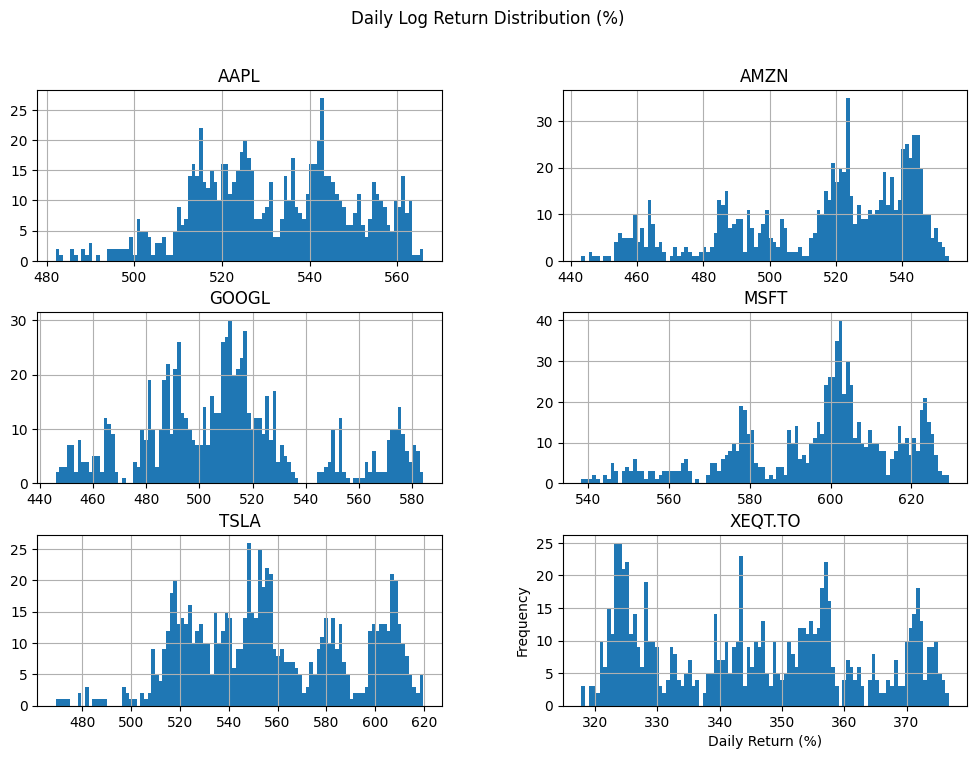

In [5]:
# Compute log returns from prices
log_returns = log_returns(prices)

# Convert to percentage to make the x-axis easier to read
log_returns_pct = log_returns * 100

# Plot distribution
log_returns_pct.hist(bins=100, figsize=(12,8))

plt.suptitle("Daily Log Return Distribution (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

In [6]:
metrics = pd.DataFrame({
    "Annual Return": annualized_return(returns),
    "Annual Volatility": annualized_volatility(returns),
    "Sharpe": sharpe_ratio(returns)
})

metrics

,Annual Return,Annual Volatility,Sharpe
AAPL,0.255096,0.253430,1.006574
AMZN,0.332530,0.315332,1.054539
GOOGL,0.430711,0.295120,1.459443
MSFT,0.193633,0.238256,0.812711
TSLA,0.569334,0.581657,0.978814
XEQT.TO,0.179760,0.119298,1.506815


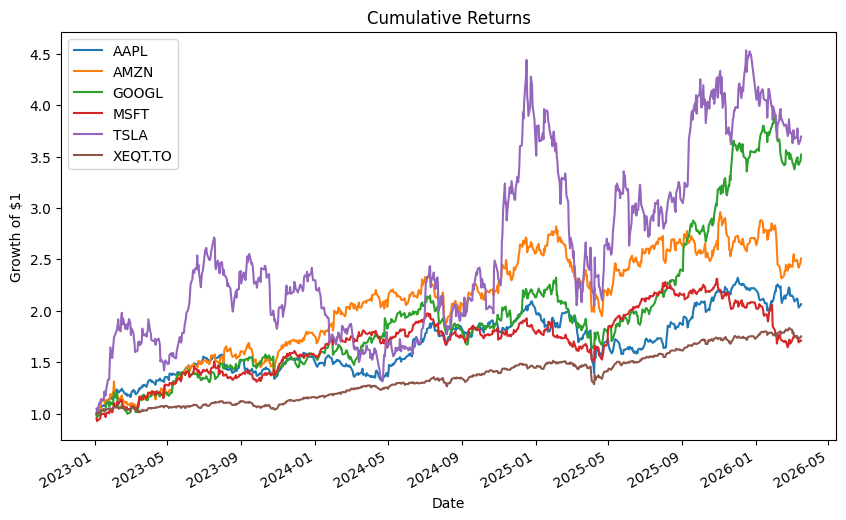

In [7]:
cum_returns = (1 + returns).cumprod()

cum_returns.plot(figsize=(10,6))
plt.title("Cumulative Returns")
plt.ylabel("Growth of $1")
plt.show()

In [8]:
weights = {
    "AAPL": 0.3,
    "MSFT": 0.3,
    "GOOGL": 0.2,
    "AMZN": 0.1,
    "TSLA": 0.1,
}

In [9]:
port_rets = portfolio_returns(returns, weights)
port_rets.head()

Date
2023-01-04   -0.008030
2023-01-05   -0.021618
2023-01-06    0.023245
2023-01-09    0.013127
2023-01-10    0.006636
dtype: float64

In [10]:
port_metrics = portfolio_metrics(port_rets)
port_metrics

Annual Return        0.310947
Annual Volatility    0.221671
Sharpe               1.402745
Max Drawdown        -0.293281
dtype: float64

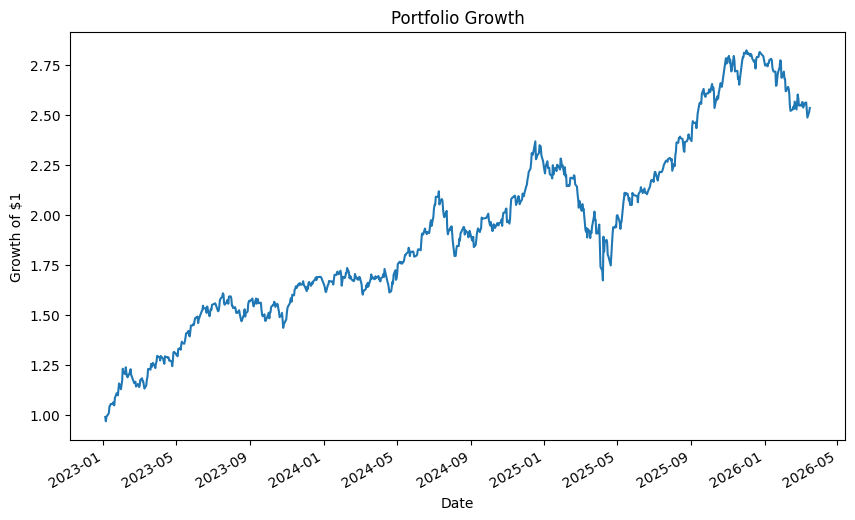

In [11]:
port_growth = portfolio_growth(port_rets)

port_growth.plot(figsize=(10, 6))
plt.title("Portfolio Growth")
plt.ylabel("Growth of $1")
plt.show()

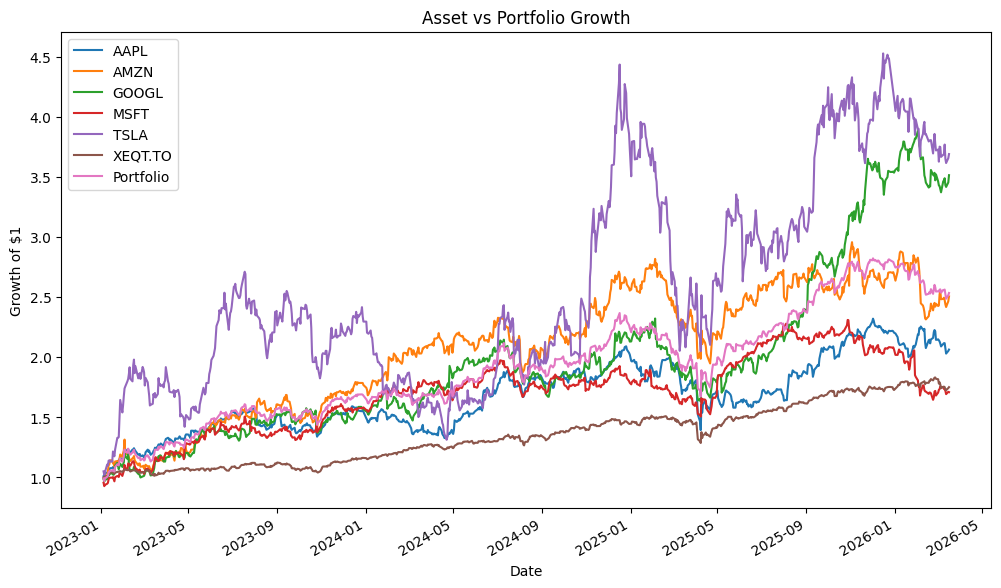

In [12]:
asset_growth = (1 + returns).cumprod()
asset_growth["Portfolio"] = port_growth

asset_growth.plot(figsize=(12, 7))
plt.title("Asset vs Portfolio Growth")
plt.ylabel("Growth of $1")
plt.show()

In [13]:
portfolios = {
    "Aggressive": {"AAPL":0.4, "MSFT":0.4, "GOOGL":0.2},
    "Balanced": {"AAPL":0.2, "MSFT":0.4, "GOOGL":0.4}
}
portfolio_returns_df = compare_portfolios(returns, portfolios)
compare_portfolios(returns, portfolios)

,Aggressive,Balanced
Date,,
2023-01-04,-0.015705,-0.020102
2023-01-05,-0.020366,-0.022514
2023-01-06,0.022077,0.017363
2023-01-09,0.007087,0.007827
2023-01-10,0.005738,0.005756
...,...,...
2026-03-11,0.000183,0.001280
2026-03-12,-0.014065,-0.013529
2026-03-13,-0.015938,-0.012365


In [14]:
portfolio_metrics_df = compare_portfolio_metrics(portfolio_returns_df)
portfolio_metrics_df

,Annual Return,Annual Volatility,Sharpe,Max Drawdown
Aggressive,0.265634,0.204813,1.296956,-0.264413
Balanced,0.300757,0.213207,1.410635,-0.252013


In [16]:
portfolio_growth_curves = portfolio_growth_df(portfolio_returns_df)
portfolio_growth_curves.head()

,Aggressive,Balanced
Date,,
2023-01-04,0.984295,0.979898
2023-01-05,0.964249,0.957837
2023-01-06,0.985536,0.974467
2023-01-09,0.992521,0.982094
2023-01-10,0.998216,0.987747


In [21]:
xeqt_returns = returns["XEQT.TO"]
xeqt_growth = portfolio_growth(xeqt_returns)
xeqt_growth.head()

Date
2023-01-04    1.000411
2023-01-05    0.996709
2023-01-06    1.009461
2023-01-09    1.009873
2023-01-10    1.016454
Name: XEQT.TO, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

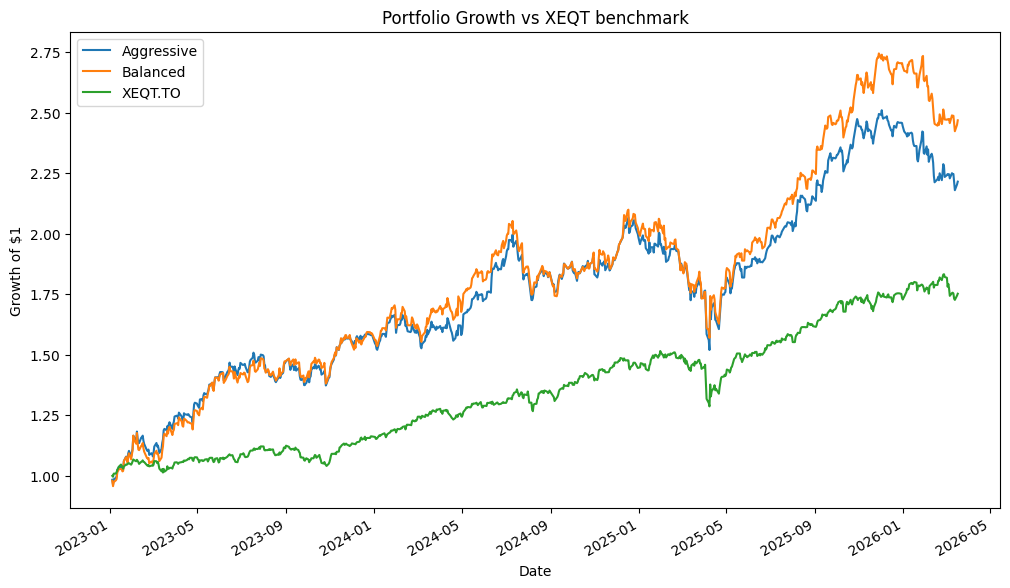

In [23]:
comparison_growth = portfolio_growth_curves.copy()
comparison_growth["XEQT.TO"] = xeqt_growth
comparison_growth.plot(figsize=(12,7))
plt.title("Portfolio Growth vs XEQT benchmark")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.show